# étoiles pulsantes
$\rightarrow$ **analyse de l'étoile RR Lyr**

<img src="./RRLyr_animation.gif" alt="RRLyr" width="500" height="400"> 

## la cible 

- RR Lyr est une étoile de type variable radiale, appartenant à la population II, avec une période de pulsation d’environ 13,6 heures.
- Elle se contracte et se dilate périodiquement, ce qui entraîne des variations de luminosité, de température, et surtout de dynamique atmosphérique.

- Lors de certaines phases de la pulsation (typiquement juste après le minimum de rayon), une onde de choc se forme dans les couches internes et remonte vers la surface.
- Ce choc est :
    - rapide : il traverse l’atmosphère en quelques dizaines de minutes,
    - violent : il accélère les couches supérieures à des vitesses de l’ordre de 100–200 km/s,
    - observable : il modifie profondément les profils spectroscopiques, notamment des raies de Balmer comme Hβ.


## les données

|||
|---|---|
|OBJECT|	rr-lyr |
|EXPTIME2|	42 x 300 s|
|BSS_ITRP|	2547|
|BSS_VHEL|	0|
|DATE-OBS|	2018-08-19T01:07:00|
|BSS_SITE|	CALC|
|BSS_INST|	ED80/600 + Dados200 + 25mic + ATIK420M|
|||






## création du dashboard
- lancer la cellule suivante
- souris sur '**Colormap**', bouton droit, menu "**Create New View for Cell Output**"
- déplacer le nouvel onglet créé '**Output View**' pour le garder visible pendant que vous naviguez et exécutez les cellules de code

En cas de souci d'affichage $\rightarrow$  '**CTRL-R**'


In [1]:
%matplotlib widget
from spectro_dashboard import SpectroDashboard

db = SpectroDashboard()
db.show()


In [42]:
import glob, os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from specutils import Spectrum
from specutils.analysis import centroid
from astropy import units as u

import numpy as np
import astropy.io.fits as fits
import imageio.v3 as imageio



spec_name = "data/plouis//@rr-lyr-4.fit"
spec = Spectrum.read(spec_name)

db.show_spectrum(spec.spectral_axis, spec.flux, label=spec.meta['header']['OBJECT'])

spec.meta

--> Affichage du spectre rr-lyr : dispersion=0.3997 Å/px


{'header': SIMPLE  =                    T / conforms to FITS standard                      
 BITPIX  =                  -32 / array data type                                
 NAXIS   =                    1 / number of array dimensions                     
 NAXIS1  =                 1426                                                  
 CRVAL1  =    4370.173158376438                                                  
 CDELT1  =   0.3997277615553685                                                  
 OBJNAME = 'rr-lyr  '                                                            
 OBJECT  = 'rr-lyr  '                                                            
 DATE-OBS= '2018-08-19T01:07:00'                                                 
 EXPTIME =                  300                                                  
 BSS_ITRP=                 2547                                                  
 SPE_RPOW=                 2547                                                  
 BSS_V

# cinématique

In [43]:
# on prépare un tableau de spectres avec les JD


files = glob.glob("../../../CAPTURES/20180818_spectro/@rr-lyr-*.fit")

# Liste temporaire pour stocker (JD, spectrum)
data = []

for f in files:
    print(f"adding {f}...")
    with warnings.catch_warnings():  # Sauvegarde et restaure les filtres
        warnings.filterwarnings('ignore')  
        spec = Spectrum.read(f)
        jd = float(spec.meta['header']['JD-OBS'])
        #jd = spec.meta['header']['JD-OBS']
        data.append((jd, spec))


# Tri par JD
data_sorted = sorted(data, key=lambda x: x[0])

# Extraction des listes finales
times   = np.array([d[0] for d in data_sorted])
spectra = [d[1] for d in data_sorted]




adding ../../../CAPTURES/20180818_spectro/@rr-lyr-6.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-35.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-21.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-20.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-34.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-7.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-5.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-22.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-36.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-37.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-23.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-4.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-27.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-33.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-32.fit...
adding ../../../CAPTURES/20180818_spectro/@rr-lyr-26.fit...
adding ../../../CAPTURES/20180818_spectro/@r

In [44]:
# on encadre la raie Hbeta

HBETA = 4861.33 * u.AA   #4875.1
WINDOW = 20 * u.AA

sub_specs = []

for spec in spectra:
    mask = (spec.spectral_axis > HBETA - WINDOW) & (spec.spectral_axis < HBETA + WINDOW)
    sub_specs.append(Spectrum(
        flux=spec.flux[mask],
        spectral_axis=spec.spectral_axis[mask]
    ))


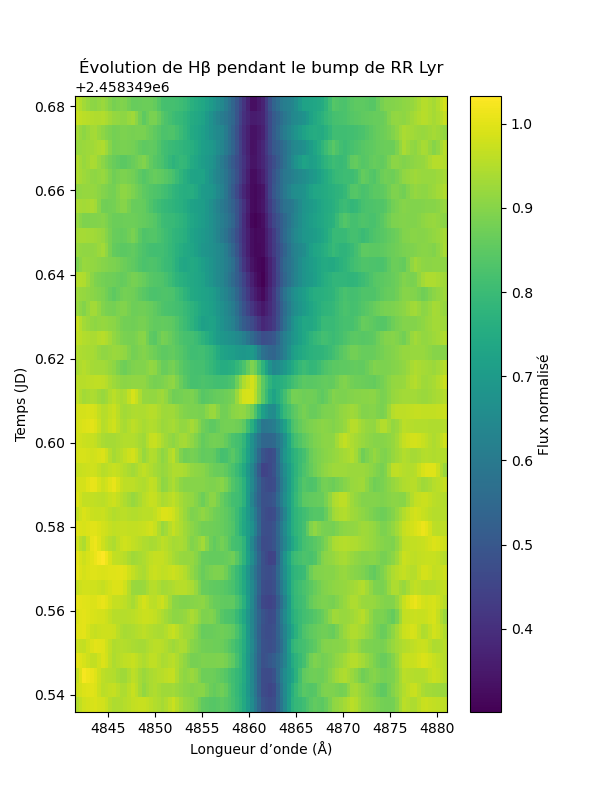

In [45]:
# On suppose que tous les spectres sont sur la même grille
lam_ref = sub_specs[0].spectral_axis.value

# on empile les spectres
flux_stack = np.vstack([s.flux.value for s in sub_specs])

#db.ax_img.extent=[lam_ref[0], lam_ref[-1], times.astype(float).min(), times.astype(float).max()],
#db.show_image(data=flux_stack, name='')

plt.figure(figsize=(6,8))
plt.imshow(flux_stack, aspect='auto', origin='lower',
           extent=[lam_ref[0], lam_ref[-1], times.astype(float).min(), times.astype(float).max()],
           cmap='viridis')
plt.xlabel("Longueur d’onde (Å)")
plt.ylabel("Temps (JD)")
plt.title("Évolution de Hβ pendant le bump de RR Lyr")
plt.colorbar(label="Flux normalisé")
plt.show()




In [61]:
# création d'une animation GIF

images = []

for spec in spectra[17:26]:

    # Création du graphique
    plt.figure()
    plt.plot(spec.spectral_axis, spec.flux)
    plt.title(spec.meta['header']['DATE-OBS'])
    plt.ylim(0.3, 1.3)
    plt.xlim(4700, 4900)
    plt.xlabel("Longueur d'onde")
    plt.ylabel("Flux")
    plt.axvline(x=4861, color='red', linestyle='--', linewidth=1, label='Hbeta')
    plt.legend()
    
    # Sauvegarde temporaire
    temp_file = 'temp.png'
    plt.savefig(temp_file)
    plt.close()
    
    # Ajout à la liste d'images
    images.append(imageio.imread(temp_file))

# Création du GIF
os.remove('temp.png')
imageio.imwrite('RRLyr_animation.gif', images, duration=500, format='GIF', loop=0)   



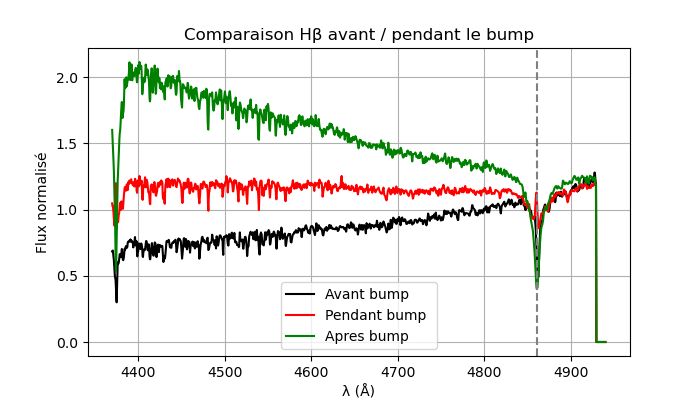

In [47]:
HBETA = 4861.33 * u.AA
i_before = 10   # spectre calme
i_bump   = 22   # spectre pendant le choc
i_after  = 32   # spectre apres le choc

def local_normalize(spec, line_center, width=15*u.AA):
    lam = spec.spectral_axis
    flux = spec.flux

    cont_mask = ((lam > line_center - width) & (lam < line_center - 5*u.AA)) | \
                ((lam > line_center + 5*u.AA) & (lam < line_center + width))

    x = lam[cont_mask].value
    y = flux[cont_mask].value

    p = np.polyfit(x, y, 1)
    cont = np.polyval(p, lam.value)

    return Spectrum(flux=flux/cont, spectral_axis=lam)

spec_before = local_normalize(spectra[i_before], HBETA)
spec_bump   = local_normalize(spectra[i_bump], HBETA)
spec_after  = local_normalize(spectra[i_after], HBETA)

lam_b = spec_before.spectral_axis.to_value()
flux_b = spec_before.flux.to_value()

lam_c = spec_bump.spectral_axis.to_value()
flux_c = spec_bump.flux.to_value()

lam_d = spec_after.spectral_axis.to_value()
flux_d = spec_after.flux.to_value()

plt.figure(figsize=(7,4))
plt.plot(lam_b, flux_b, 'k-', label=f"Avant bump")
plt.plot(lam_c, flux_c, 'r-', label=f"Pendant bump ")
plt.plot(lam_d, flux_d, 'g-', label=f"Apres bump ")
plt.axvline(HBETA.value, color='gray', ls='--') #, label="Hβ repos")
plt.xlabel("λ (Å)")
plt.ylabel("Flux normalisé")
plt.title("Comparaison Hβ avant / pendant le bump")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
from scipy.signal import find_peaks

def vitesse_choc(spec, center=4861.33, window=8):
    lam = spec.spectral_axis.to_value()
    flux = spec.flux.to_value()

    mask = (lam > center - window) & (lam < center + window)
    lam_w = lam[mask]
    flux_w = flux[mask]

    # Détection des pics d’émission
    peaks, props = find_peaks(flux_w, prominence=0.02)
    if len(peaks) == 0:
        return np.nan

    # Choisir le pic le plus proche de Hβ
    i_best = np.argmin(np.abs(lam_w[peaks] - center))
    lam_em = lam_w[peaks[i_best]]

    # Vitesse Doppler
    c = 299792.458
    v = c * (lam_em - center) / center

    """
    plt.figure(figsize=(7,4))
    plt.plot(lam_w, flux_w, 'r-')
    plt.axvline(4861.33, color='gray', ls='--', label="Hβ repos")
    plt.axvline(lam_em, color='b', ls=':', label=f"Pic émission ({v:.1f} km/s)")
    plt.legend()
    plt.xlabel("λ (Å)")
    plt.ylabel("Flux norm.")
    plt.title("Pic d’émission Hβ pendant le bump")
    plt.grid(True)
    plt.show()
    """

    return v


In [51]:
spec_bump = local_normalize(spectra[i_bump], HBETA)
v_choc = vitesse_choc(spec_bump)
print(f"Vitesse du choc ≈ {v_choc:.1f} km/s")


Vitesse du choc ≈ -67.3 km/s


In [52]:
from scipy.signal import find_peaks
import numpy as np

def vitesse_choc(spec, center=4861.33, window=8, min_height=1.02, min_prom=0.02):
    lam = spec.spectral_axis.to_value()
    flux = spec.flux.to_value()

    mask = (lam > center - window) & (lam < center + window)
    lam_w = lam[mask]
    flux_w = flux[mask]

    # on ne cherche des pics que au-dessus du continuum
    peaks, props = find_peaks(flux_w, height=min_height, prominence=min_prom)
    if len(peaks) == 0:
        return np.nan

    i_best = np.argmin(np.abs(lam_w[peaks] - center))
    lam_em = lam_w[peaks[i_best]]

    c = 299792.458
    return c * (lam_em - center) / center


In [53]:
v_choc = np.array([vitesse_choc(local_normalize(s, HBETA)) for s in spectra])
v_choc_masked = np.where((times > 0.60) & (times < 0.64), v_choc, np.nan)


In [54]:
from specutils.analysis import centroid

def vr_centroid(spec):
    spec_n = local_normalize(spec, HBETA)
    mask = (spec_n.spectral_axis > HBETA - 8*u.AA) & (spec_n.spectral_axis < HBETA + 8*u.AA)
    sub = Spectrum(flux=1 - spec_n.flux[mask], spectral_axis=spec_n.spectral_axis[mask])
    c_lam = centroid(sub).to(u.AA).value
    return 299792.458 * (c_lam - HBETA.value) / HBETA.value

vr_abs = np.array([vr_centroid(s) for s in spectra])


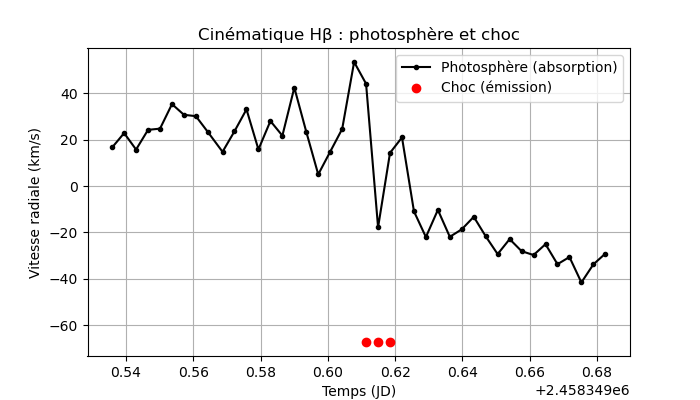

In [55]:
plt.figure(figsize=(7,4))
plt.plot(times, vr_abs, "k.-", label="Photosphère (absorption)")
plt.plot(times, v_choc, "ro", label="Choc (émission)")
plt.xlabel("Temps (JD)")
plt.ylabel("Vitesse radiale (km/s)")
plt.legend(loc='upper right')
plt.grid(True)
plt.title("Cinématique Hβ : photosphère et choc")
plt.show()


# analyse

Pendant le passage du choc :

| Comportement	| Interprétation| 
| ---| ---|
| Emission partielle de la raie Hβ	|Un gaz chaud et excité apparaît| 
| Inversion partielle (absorption → émission)| Le choc chauffe et ionise les couches supérieures| 
| Décalage Doppler du pic d’émission| 	Mesure directe de la vitesse de la couche choquée| 
| Élargissement de la raie (FWHM)	| Turbulence et gradients de vitesse dans la zone de choc| 


- C'est similaire à une cocotte minute dont le couvercle se soulève à cause de la pression -> la température chute
- La contraction est si brutale que l’énergie cinétique se transforme en onde de choc.
- Elle traverse l’atmosphère, chauffe, ionise, et accélère les couches externes.
- Elle est visible dans les raies spectrales, surtout Hα, Hβ, Hγ, parfois Na D ou Ca II K.


In [56]:
# Au cas ou : pour ajouter un JD valide

import glob
from astropy.io import fits
from astropy.time import Time

# Fichiers bruts et réduits
raw_files = sorted(glob.glob("../../../CAPTURES/20180818_spectro/rrLyr-*.fit"))
red_files = sorted(glob.glob("../../../CAPTURES/20180818_spectro/@rr-lyr-*.fit"))

print("Bruts :", len(raw_files))
print("Réduits :", len(red_files))

if len(raw_files) != len(red_files):
    print("⚠ Attention : le nombre de bruts et de réduits ne correspond pas !")

# Fonction pour extraire un JD depuis un header brut
def extract_jd(hdr):
    # 1) Cas le plus simple : JD directement présent
    if "JD" in hdr:
        return hdr["JD"]

    # 2) MJD
    if "MJD-OBS" in hdr:
        return Time(hdr["MJD-OBS"], format="mjd").jd

    # 3) DATE-OBS complet
    if "DATE-OBS" in hdr:
        try:
            return Time(hdr["DATE-OBS"]).jd
        except:
            pass

    # 4) DATE-OBS + UTSTART
    if "DATE-OBS" in hdr and "UTSTART" in hdr:
        date = hdr["DATE-OBS"]
        ut = hdr["UTSTART"]
        try:
            return Time(f"{date}T{ut}").jd
        except:
            pass

    # 5) Rien trouvé
    return None


# Boucle principale : associer brut → réduit
for raw, red in zip(raw_files, red_files):
    hdr_raw = fits.getheader(raw)
    jd = extract_jd(hdr_raw)

    if jd is None:
        print(f"⚠ Impossible d'extraire JD pour {raw}")
        continue

    # Ouvrir le FITS réduit en mode update
    with fits.open(red, mode="update") as hdul:
        hdul[0].header["JD"] = jd
        hdul.flush()

    print(f"JD ajouté à {red} : {jd}")


Bruts : 42
Réduits : 42
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-1.fit : 2458349.5358564816
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-10.fit : 2458349.5686805556
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-11.fit : 2458349.572233796
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-12.fit : 2458349.575798611
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-13.fit : 2458349.5793518517
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-14.fit : 2458349.5829050927
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-15.fit : 2458349.5864699073
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-16.fit : 2458349.5900231483
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-17.fit : 2458349.593576389
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-18.fit : 2458349.5971296295
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-19.fit : 2458349.6006944445
JD ajouté à ../../../CAPTURES/20180818_spectro/@rr-lyr-2.fit : 2458